In [257]:
# importing libraries 
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [258]:
dataset = pd.read_csv('datasets/crop_yield.csv')
print(dataset.head())

           Crop  Crop_Year       Season  State     Area  Production  \
0      Arecanut       1997  Whole Year   Assam  73814.0       56708   
1     Arhar/Tur       1997  Kharif       Assam   6637.0        4685   
2   Castor seed       1997  Kharif       Assam    796.0          22   
3      Coconut        1997  Whole Year   Assam  19656.0   126905000   
4  Cotton(lint)       1997  Kharif       Assam   1739.0         794   

   Annual_Rainfall  Fertilizer  Pesticide        Yield  
0           2051.4  7024878.38   22882.34     0.796087  
1           2051.4   631643.29    2057.47     0.710435  
2           2051.4    75755.32     246.76     0.238333  
3           2051.4  1870661.52    6093.36  5238.051739  
4           2051.4   165500.63     539.09     0.420909  


<span style="color:red"> Supervised and its a regression problem since continuous/non categorical values in output</span>

In [259]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [260]:
# check for null values 
dataset.isnull().sum()

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

In [261]:
dataset.duplicated().sum()
# dataset.drop_duplicates(inplace=True)
# dataset.duplicated().sum()


np.int64(0)

In [262]:
dataset.shape
dataset.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000


# data visualization

In [263]:
print(len(dataset['Crop'].unique())) #55
print(dataset['Crop'].unique())

55
['Arecanut' 'Arhar/Tur' 'Castor seed' 'Coconut ' 'Cotton(lint)'
 'Dry chillies' 'Gram' 'Jute' 'Linseed' 'Maize' 'Mesta' 'Niger seed'
 'Onion' 'Other  Rabi pulses' 'Potato' 'Rapeseed &Mustard' 'Rice'
 'Sesamum' 'Small millets' 'Sugarcane' 'Sweet potato' 'Tapioca' 'Tobacco'
 'Turmeric' 'Wheat' 'Bajra' 'Black pepper' 'Cardamom' 'Coriander' 'Garlic'
 'Ginger' 'Groundnut' 'Horse-gram' 'Jowar' 'Ragi' 'Cashewnut' 'Banana'
 'Soyabean' 'Barley' 'Khesari' 'Masoor' 'Moong(Green Gram)'
 'Other Kharif pulses' 'Safflower' 'Sannhamp' 'Sunflower' 'Urad'
 'Peas & beans (Pulses)' 'other oilseeds' 'Other Cereals' 'Cowpea(Lobia)'
 'Oilseeds total' 'Guar seed' 'Other Summer Pulses' 'Moth']


In [264]:
len(dataset['State'].unique())


30

In [265]:
dataset['Season'] = dataset['Season'].str.strip().str.title()

In [266]:
print(dataset['Season'].unique()) # 6 seasons 


['Whole Year' 'Kharif' 'Rabi' 'Autumn' 'Summer' 'Winter']


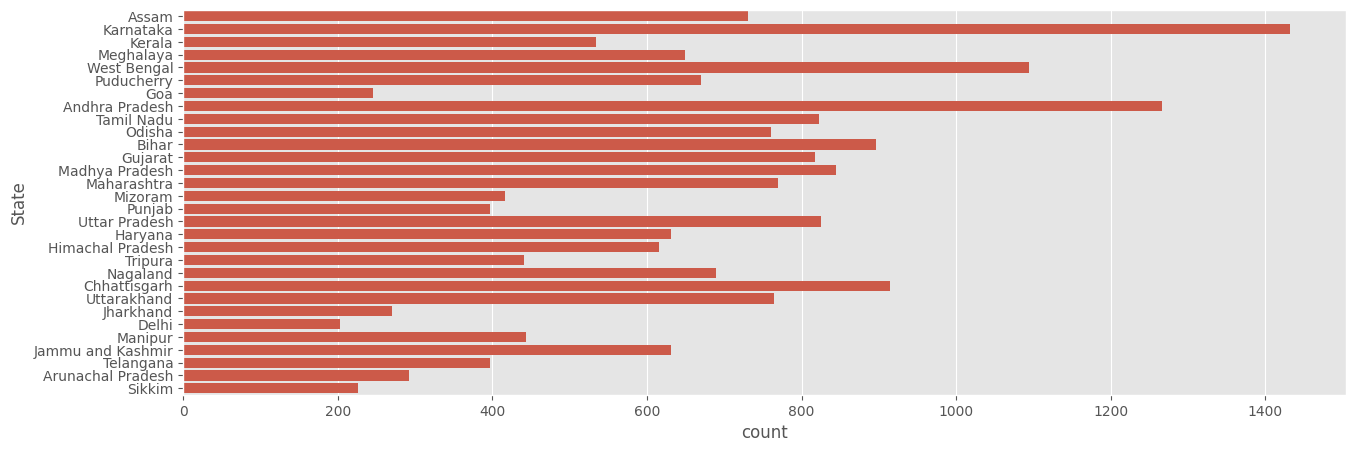

In [267]:
plt.figure(figsize=(15,5))
sns.countplot(y = dataset['State'])
plt.show()

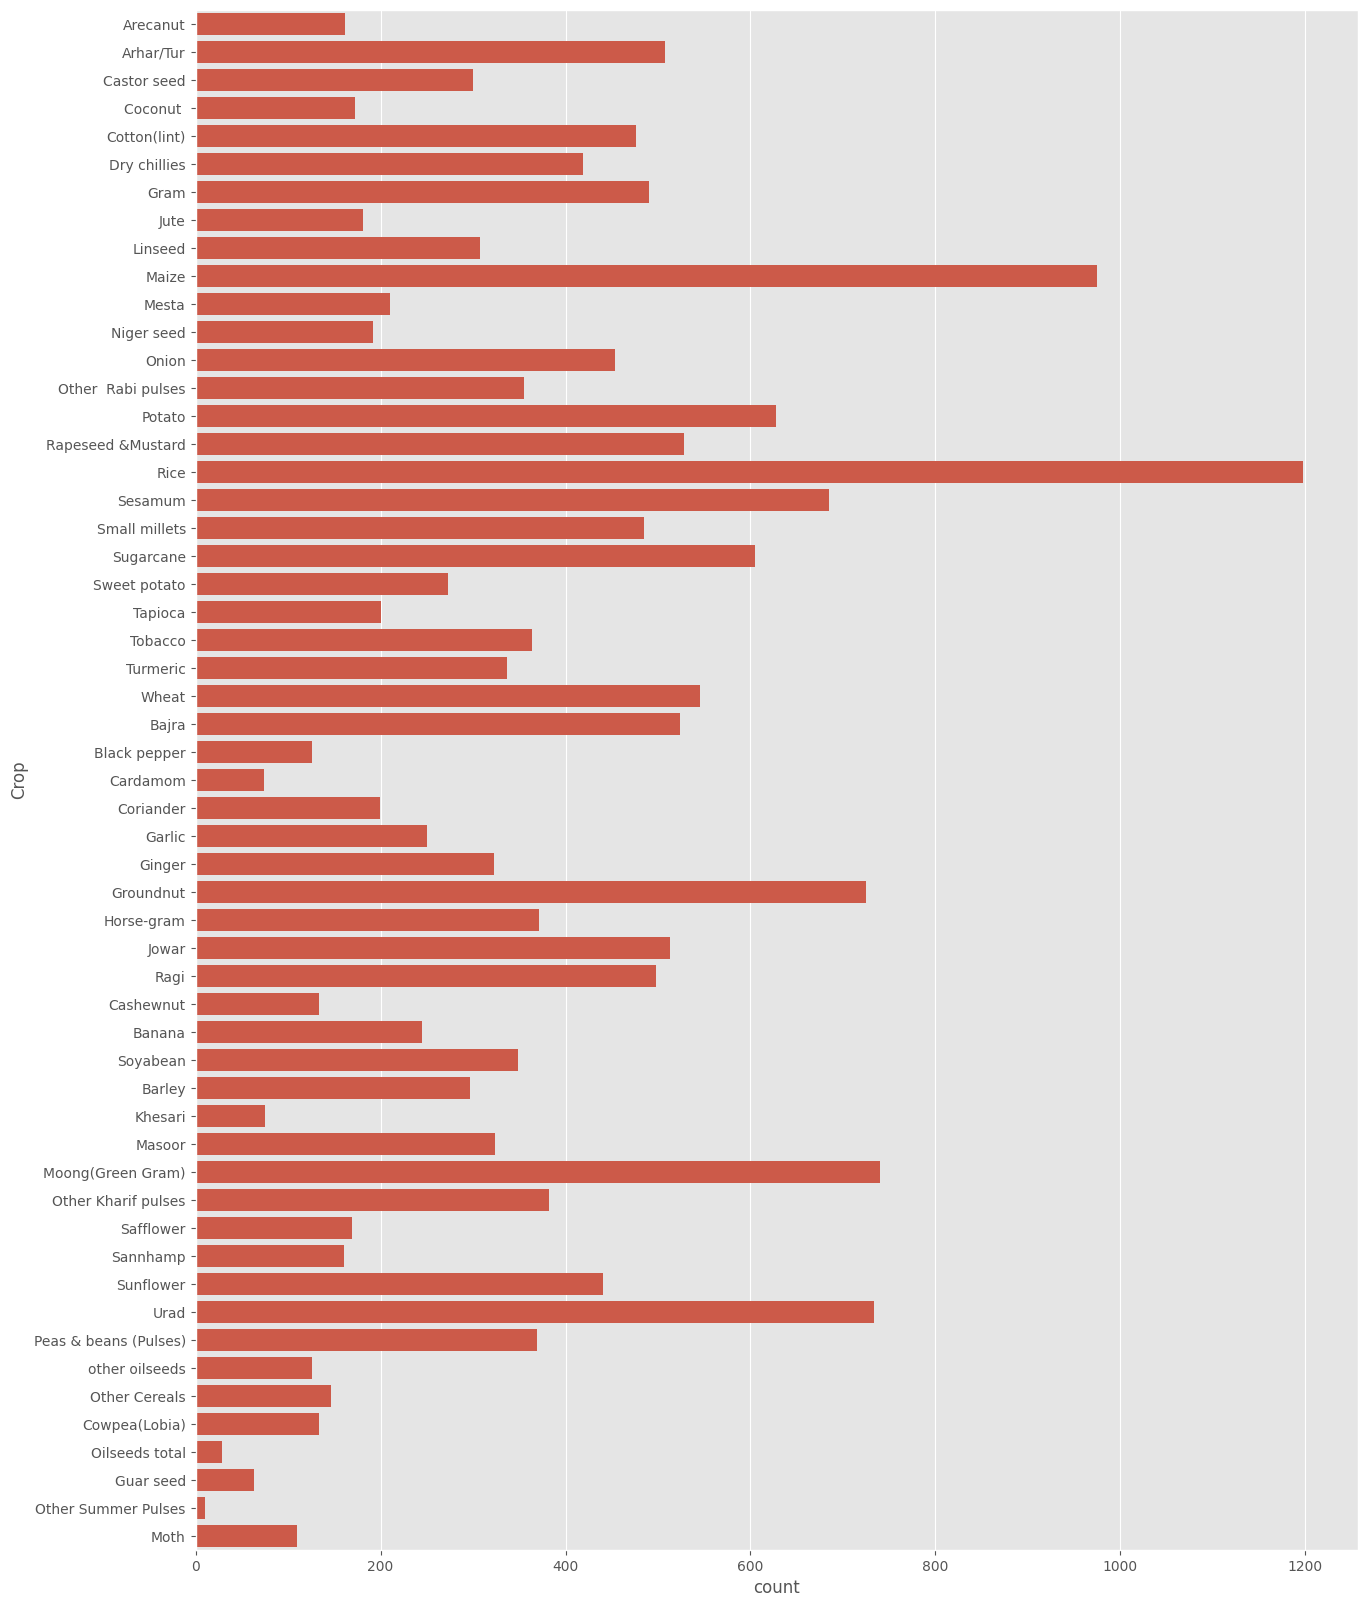

In [268]:
plt.figure(figsize=(15,20))
sns.countplot(y = dataset['Crop'])
plt.show()

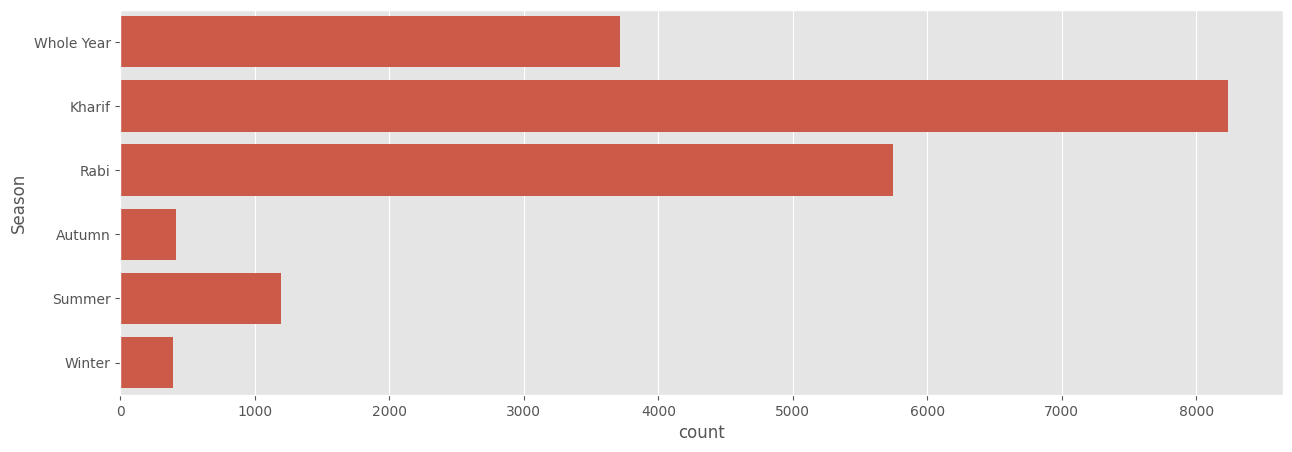

In [269]:
plt.figure(figsize=(15,5))
sns.countplot(y = dataset['Season'])
plt.show()

In [270]:
# column transfers for less code so that we dont need to write code for every column s

dataset.columns

Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield'],
      dtype='object')

In [271]:
col = ['Crop_Year','Area', 'Production','Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Crop','Season','State', 'Yield']


In [272]:
dataset = dataset[col]
dataset.head()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Crop,Season,State,Yield
0,1997,73814.0,56708,2051.4,7024878.38,22882.34,Arecanut,Whole Year,Assam,0.796087
1,1997,6637.0,4685,2051.4,631643.29,2057.47,Arhar/Tur,Kharif,Assam,0.710435
2,1997,796.0,22,2051.4,75755.32,246.76,Castor seed,Kharif,Assam,0.238333
3,1997,19656.0,126905000,2051.4,1870661.52,6093.36,Coconut,Whole Year,Assam,5238.051739
4,1997,1739.0,794,2051.4,165500.63,539.09,Cotton(lint),Kharif,Assam,0.420909


In [273]:
X = dataset.drop('Yield', axis=1)
y = dataset['Yield']

In [274]:
X.shape

(19689, 9)

In [275]:
y.shape

(19689,)

In [276]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0 , shuffle=True)

In [277]:
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.compose import ColumnTransformer

ohe = OneHotEncoder(drop = 'first', handle_unknown='ignore')
scale = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        
        ('StandardScale', scale , [0,1,2,3,4,5]), #3 tuples 
        ('OneHotEncoder', ohe, [6,7,8])
    ],
    remainder='passthrough'
)

In [278]:
print(dataset['Season'].unique())

['Whole Year' 'Kharif' 'Rabi' 'Autumn' 'Summer' 'Winter']


In [279]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


In [280]:
preprocessor.get_feature_names_out(col[:-1])

array(['StandardScale__Crop_Year', 'StandardScale__Area',
       'StandardScale__Production', 'StandardScale__Annual_Rainfall',
       'StandardScale__Fertilizer', 'StandardScale__Pesticide',
       'OneHotEncoder__Crop_Arhar/Tur', 'OneHotEncoder__Crop_Bajra',
       'OneHotEncoder__Crop_Banana', 'OneHotEncoder__Crop_Barley',
       'OneHotEncoder__Crop_Black pepper', 'OneHotEncoder__Crop_Cardamom',
       'OneHotEncoder__Crop_Cashewnut', 'OneHotEncoder__Crop_Castor seed',
       'OneHotEncoder__Crop_Coconut ', 'OneHotEncoder__Crop_Coriander',
       'OneHotEncoder__Crop_Cotton(lint)',
       'OneHotEncoder__Crop_Cowpea(Lobia)',
       'OneHotEncoder__Crop_Dry chillies', 'OneHotEncoder__Crop_Garlic',
       'OneHotEncoder__Crop_Ginger', 'OneHotEncoder__Crop_Gram',
       'OneHotEncoder__Crop_Groundnut', 'OneHotEncoder__Crop_Guar seed',
       'OneHotEncoder__Crop_Horse-gram', 'OneHotEncoder__Crop_Jowar',
       'OneHotEncoder__Crop_Jute', 'OneHotEncoder__Crop_Khesari',
       'OneHotEn

In [281]:
from sklearn.linear_model import LinearRegression , Lasso , Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import median_absolute_error , r2_score , accuracy_score


In [282]:
models = {
    'Linear Regression': LinearRegression(),
    'Lasso' : Lasso(),
    'Ridge' : Ridge(),
    'Decision Tree' : DecisionTreeRegressor(), 
    # 'Random Forest' : RandomForestRegressor(),
    'KNN' : KNeighborsRegressor()
    
}

for name , model_names in models.items():
    model_names.fit(X_train , y_train)
    y_pred = model_names.predict(X_test)
    print(f'{name} The mean absolute error : {median_absolute_error(y_test, y_pred)} , The r2 score{r2_score(y_test, y_pred)}')

Linear Regression The mean absolute error : 19.85017569792159 , The r2 score0.854350554771411
Lasso The mean absolute error : 11.41151683730862 , The r2 score0.8506379457943178
Ridge The mean absolute error : 20.314373672231245 , The r2 score0.8526515274374293
Decision Tree The mean absolute error : 0.11033333300000003 , The r2 score0.9436101748246574
KNN The mean absolute error : 0.1452139864 , The r2 score0.9435937523627809


In [287]:
knn = DecisionTreeRegressor()
knn.fit(X_train, y_train)
knn.predict(X_test)



array([38.00357143,  5.57851852,  0.615     , ...,  4.32809524,
        0.253125  ,  1.228     ])

predict system

In [288]:
dataset.columns

Index(['Crop_Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer',
       'Pesticide', 'Crop', 'Season', 'State', 'Yield'],
      dtype='object')

# testing the model on test data 

In [289]:
def prediction(Crop_Year, Area, Production, Annual_Rainfall, Fertilizer, Pesticide, Crop, Season, State):
    # Create a 2D array with one sample
    features = np.array([[Crop_Year, Area, Production, Annual_Rainfall, Fertilizer, Pesticide, Crop, Season, State]])
    
    # Transform the features using the preprocessor
    transform_features = preprocessor.transform(features)
    
    # Make prediction
    predicted_yield = knn.predict(transform_features).reshape(-1, 1)
    
    return predicted_yield[0][0]

print(prediction(1997, 73814, 56708, 2051, 7024878, 22882, "Arecanut", "Whole Year", "Assam"))


0.796086957


c:\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


In [291]:
import joblib
joblib.dump(knn,'Modelss/Final_CropYieldPrediction.pkl')
joblib.dump(preprocessor,'Modelss/Final_ProcessorCropYield.pkl')

['Modelss/Final_ProcessorCropYield.pkl']